In [2]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_curve, roc_auc_score, RocCurveDisplay)
import matplotlib.pyplot as plt
import DecompensationImputed

## Data

In [3]:
X, y = DecompensationImputed.load_data(sample_size=100000, icu_vitals=True, top_n_labs=230, top_n_drugs=954, top_n_procedures=55)

Returing 100000 patient records with 675 columns. y distribution: 
0    0.97126
1    0.02874
Name: proportion, dtype: float64


In [4]:
# 80/20 train-test, need to switch to train-validate-test once were comparing models
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (80000, 675), Test: (20000, 675)


In [5]:
X.head(20)

,los_hours,anchor_age,gender_female,bp_systolic,bp_diastolic,result_value_x,result_value_y,vital_heart_rate,vital_respiratory_rate,vital_spo2,...,race_PATIENT DECLINED TO ANSWER,race_PORTUGUESE,race_SOUTH AMERICAN,race_UNABLE TO OBTAIN,race_UNKNOWN,race_WHITE,race_WHITE - BRAZILIAN,race_WHITE - EASTERN EUROPEAN,race_WHITE - OTHER EUROPEAN,race_WHITE - RUSSIAN
0,107.516667,57,0,124.0,72.0,170.0,65.5,82.5,19.131007,96.4,...,0,0,0,0,0,1,0,0,0,0
1,94.216667,65,1,124.0,72.0,170.0,65.5,82.5,19.131007,96.4,...,0,0,0,0,0,1,0,0,0,0
2,80.533333,43,0,124.0,72.0,170.0,65.5,82.5,19.131007,96.4,...,0,0,0,0,0,0,0,0,0,0
3,79.000000,41,1,124.0,72.0,170.0,64.0,82.5,19.131007,96.4,...,0,0,0,0,0,0,0,0,0,0
4,89.366667,35,1,124.0,72.0,170.0,65.5,82.5,19.131007,96.4,...,0,0,0,0,0,1,0,0,0,0
5,312.683333,63,0,124.0,72.0,170.0,72.0,82.5,19.131007,96.4,...,0,0,0,0,0,1,0,0,0,0
6,274.283333,56,0,124.0,72.0,170.0,65.5,82.5,19.131007,96.4,...,0,0,0,0,0,1,0,0,0,0
7,113.716667,39,1,124.0,72.0,170.0,65.5,82.5,19.131007,96.4,...,0,0,0,0,0,0,0,0,0,0
8,271.850000,26,1,124.0,72.0,170.0,65.5,82.5,19.131007,96.4,...,0,0,0,0,0,1,0,0,0,0
9,163.300000,50,0,124.0,72.0,170.0,65.5,82.5,19.131007,96.4,...,0,0,0,0,0,1,0,0,0,0


## Logistic Regression (scaled and class weighted)

In [8]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [9]:
model = LogisticRegression(C=0.2, class_weight='balanced', max_iter=10000)
model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.2
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

Confusion matrix:
                Pred 0   Pred 1
  Actual 0       18177     1248   (specificity 0.936)
  Actual 1          88      487   (sensitivity 0.847)

TPR (sensitivity):  0.847
FPR (fall-out):     0.064
Precision:          0.281
ROC-AUC:            0.955

              precision    recall  f1-score   support

    Survived       1.00      0.94      0.96     19425
        Died       0.28      0.85      0.42       575

    accuracy                           0.93     20000
   macro avg       0.64      0.89      0.69     20000
weighted avg       0.97      0.93      0.95     20000



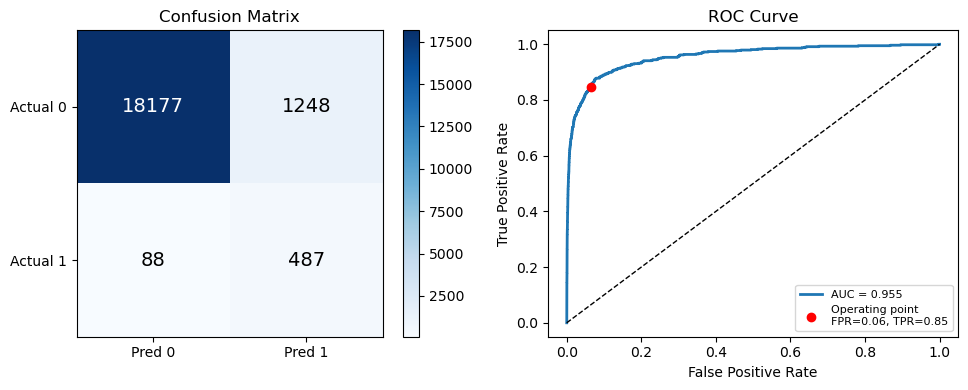

In [10]:
y_pred  = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

# --- Confusion matrix ---
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
tpr = tp / (tp + fn)   # sensitivity / recall
fpr = fp / (fp + tn)   # fall-out
tnr = tn / (tn + fp)   # specificity
ppv = tp / (tp + fp)   # precision

print("Confusion matrix:")
print(f"  {'':12s}  Pred 0   Pred 1")
print(f"  {'Actual 0':12s}  {tn:>6}   {fp:>6}   (specificity {tnr:.3f})")
print(f"  {'Actual 1':12s}  {fn:>6}   {tp:>6}   (sensitivity {tpr:.3f})")
print()
print(f"TPR (sensitivity):  {tpr:.3f}")
print(f"FPR (fall-out):     {fpr:.3f}")
print(f"Precision:          {ppv:.3f}")
print(f"ROC-AUC:            {roc_auc_score(y_test, y_proba):.3f}")
print()
print(classification_report(y_test, y_pred, target_names=['Survived', 'Died']))

# --- Plots ---
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Confusion matrix heatmap
im = axes[0].imshow(cm, cmap='Blues')
axes[0].set_xticks([0, 1]); axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(['Pred 0', 'Pred 1'])
axes[0].set_yticklabels(['Actual 0', 'Actual 1'])
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, cm[i, j], ha='center', va='center',
                     color='white' if cm[i, j] > cm.max() / 2 else 'black', fontsize=14)
axes[0].set_title('Confusion Matrix')
plt.colorbar(im, ax=axes[0])

# ROC curve
fpr_curve, tpr_curve, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)
axes[1].plot(fpr_curve, tpr_curve, lw=2, label=f'AUC = {auc:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].scatter([fpr], [tpr], color='red', zorder=5, label=f'Operating point\nFPR={fpr:.2f}, TPR={tpr:.2f}')
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve'); axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

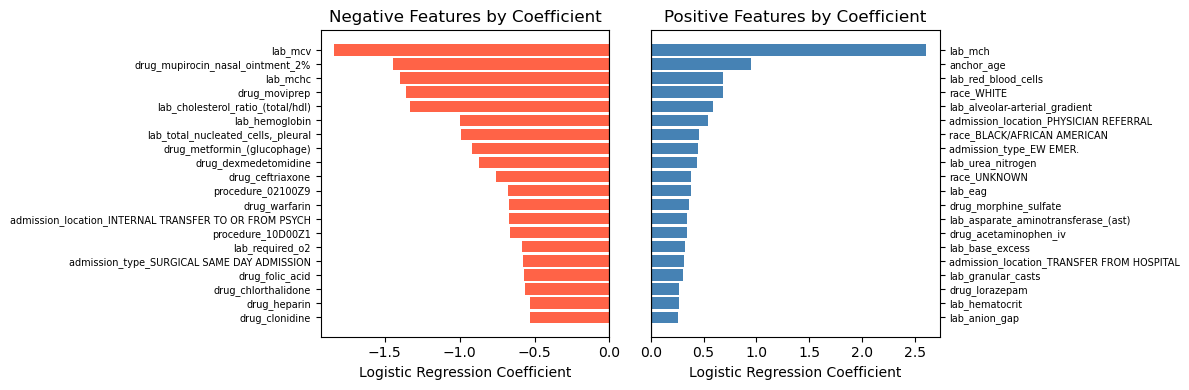

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Top feature coefficients
coef_series = pd.Series(model.coef_[0], index=X.columns)
top__neg_coef = coef_series[coef_series != 0].sort_values(ascending=True).head(20)
signed_top = coef_series[top__neg_coef.index]
axes[0].barh(signed_top.index[::-1], signed_top.values[::-1], color='tomato')
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_xlabel('Logistic Regression Coefficient')
axes[0].set_title('Negative Features by Coefficient')
axes[0].tick_params(axis='y', labelsize=7)

coef_series = pd.Series(model.coef_[0], index=X.columns)
top_pos_coef = coef_series[coef_series != 0].sort_values(ascending=False).head(20)
signed_top = coef_series[top_pos_coef.index]
axes[1].barh(signed_top.index[::-1], signed_top.values[::-1], color='steelblue')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('Logistic Regression Coefficient')
axes[1].set_title('Positive Features by Coefficient')
axes[1].tick_params(axis='y', labelsize=7)
axes[1].yaxis.set_label_position("right")
axes[1].yaxis.tick_right()

plt.tight_layout()
plt.show()

In [ ]:
coef_series = pd.Series(model.coef_[0], index=X.columns)
print("Top 20 POSITIVE coefficients:")
print(coef_series.sort_values(ascending=False).head(20).to_string())
print("\nTop 20 NEGATIVE coefficients:")
print(coef_series.sort_values(ascending=True).head(20).to_string())

## Lasso CV (scaled and class weighted)

In [ ]:
# Logistic regression with L1 penalty and 20 different regularization strengths
model = LogisticRegressionCV(
    Cs=np.logspace(-4, 1, 20),
    cv=5,
    l1_ratios=(1,),
    solver='saga',
    max_iter=800,
    tol=1e-4,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=2,
    class_weight='balanced'
)
model.fit(X_train_scaled, y_train)

best_C = model.C_[0]
print(f"Best C: {best_C:.6f}")
print(f"Non-zero coefficients: {np.sum(model.coef_[0] != 0)} / {len(model.coef_[0])}")

In [ ]:
import joblib
joblib.dump(model, 'results/decompensation_lasso_model.joblib')

In [ ]:
coef_series = pd.Series(model.coef_[0], index=X.columns)
coef_series = coef_series.sort_values()
coef_series.to_csv('results/decompensation_coef_series.csv')

In [ ]:
drug_coef = coef_series[coef_series.index.str.startswith('drug_')].sort_values()
lab_coef = coef_series[coef_series.index.str.startswith('lab_')].sort_values()
procedure_coef = coef_series[coef_series.index.str.startswith('procedure_')].sort_values()

print(f"Non-zero drugs: {np.sum(drug_coef != 0)} / {len(drug_coef)}")
print(f"Non-zero labs: {np.sum(lab_coef != 0)} / {len(lab_coef)}")
print(f"Non-zero procedures: {np.sum(procedure_coef != 0)} / {len(procedure_coef)}")

In [ ]:
y_pred  = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

# --- Confusion matrix ---
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
tpr = tp / (tp + fn)   # sensitivity / recall
fpr = fp / (fp + tn)   # fall-out
tnr = tn / (tn + fp)   # specificity
ppv = tp / (tp + fp)   # precision

print("Confusion matrix:")
print(f"  {'':12s}  Pred 0   Pred 1")
print(f"  {'Actual 0':12s}  {tn:>6}   {fp:>6}   (specificity {tnr:.3f})")
print(f"  {'Actual 1':12s}  {fn:>6}   {tp:>6}   (sensitivity {tpr:.3f})")
print()
print(f"TPR (sensitivity):  {tpr:.3f}")
print(f"FPR (fall-out):     {fpr:.3f}")
print(f"Precision:          {ppv:.3f}")
print(f"ROC-AUC:            {roc_auc_score(y_test, y_proba):.3f}")
print()
print(classification_report(y_test, y_pred, target_names=['Survived', 'Died']))

# --- Plots ---
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Confusion matrix heatmap
im = axes[0].imshow(cm, cmap='Blues')
axes[0].set_xticks([0, 1]); axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(['Pred 0', 'Pred 1'])
axes[0].set_yticklabels(['Actual 0', 'Actual 1'])
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, cm[i, j], ha='center', va='center',
                     color='white' if cm[i, j] > cm.max() / 2 else 'black', fontsize=14)
axes[0].set_title('Confusion Matrix')
plt.colorbar(im, ax=axes[0])

# ROC curve
fpr_curve, tpr_curve, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)
axes[1].plot(fpr_curve, tpr_curve, lw=2, label=f'AUC = {auc:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].scatter([fpr], [tpr], color='red', zorder=5, label=f'Operating point\nFPR={fpr:.2f}, TPR={tpr:.2f}')
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve'); axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('results/decompensation_lasso_results.png', dpi=120, bbox_inches='tight')
plt.show()

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Top feature coefficients
coef_series = pd.Series(model.coef_[0], index=X.columns)
top__neg_coef = coef_series[coef_series != 0].sort_values(ascending=True).head(20)
signed_top = coef_series[top__neg_coef.index]
axes[0].barh(signed_top.index[::-1], signed_top.values[::-1], color='tomato')
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_xlabel('Logistic Regression Coefficient')
axes[0].set_title('Negative Features by Coefficient')
axes[0].tick_params(axis='y', labelsize=7)

coef_series = pd.Series(model.coef_[0], index=X.columns)
top_pos_coef = coef_series[coef_series != 0].sort_values(ascending=False).head(20)
signed_top = coef_series[top_pos_coef.index]
axes[1].barh(signed_top.index[::-1], signed_top.values[::-1], color='steelblue')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('Logistic Regression Coefficient')
axes[1].set_title('Positive Features by Coefficient')
axes[1].tick_params(axis='y', labelsize=7)
axes[1].yaxis.set_label_position("right")
axes[1].yaxis.tick_right()

plt.tight_layout()
plt.show()